Base consolidada: 510842 predições de clusters esparsos mineradas com sucesso.


,Modelo,MAPE (Sem Zeros) %,sMAPE Bruto (%),sMAPE Pós (%),WAPE Bruto (%),WAPE Pós (%),Falsos Alertas Evitados
0,Baseline,107.58,61.22,61.22,76.62,76.62,19
1,XGBoost,73.93,112.81,56.06,57.59,55.02,37723
2,GRU,79.00,128.22,61.15,63.08,60.87,43566
3,LSTM,82.59,129.34,121.72,121.71,121.41,5039


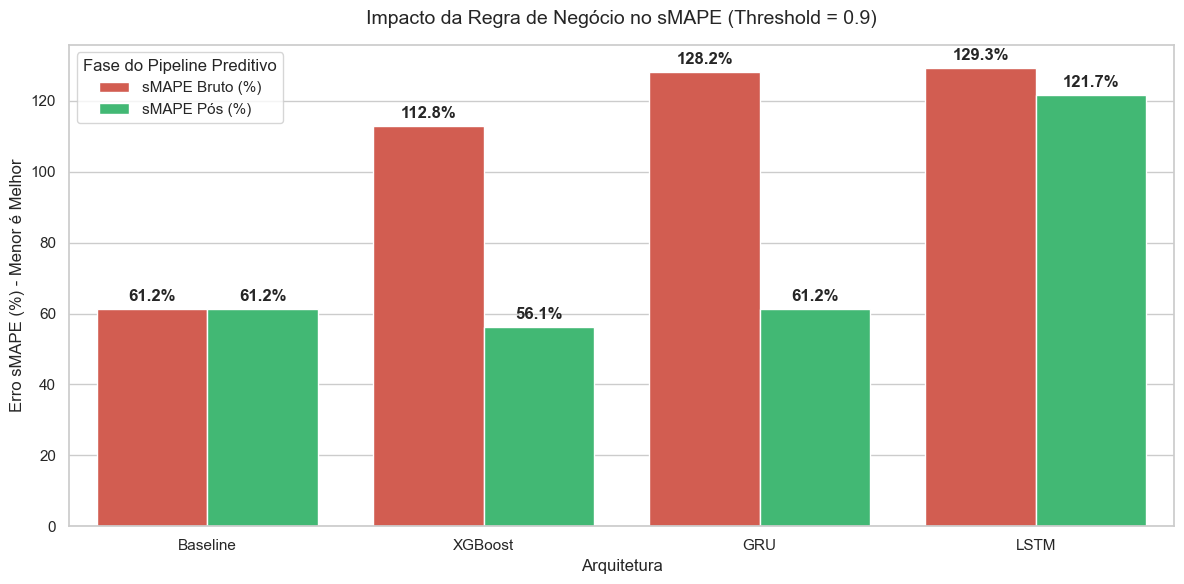

In [2]:
# %% [markdown]
# # Pós-Processamento e Segmentação de Erros (Error Analysis Comparativo)
# 
# ## Objetivo
# Analisar as previsões brutas de todas as arquiteturas avaliadas em cenários de demanda esparsa, aplicando heurísticas de pós-processamento (Thresholding) para comparar a sensibilidade de cada modelo ao ruído matemático diário.
# 
# ## Contextualização
# Modelos preditivos reagem de forma diferente à intermitência do varejo. O *Baseline* copia zeros passados, o *XGBoost* isola zeros através de ramificações lógicas, e arquiteturas de *Deep Learning* (LSTM/GRU) aproximam-se do zero via funções de ativação contínuas, gerando ruídos residuais (ex: prever `0.6` em um dia de venda zero).
# 
# Este notebook consolida as previsões dos modelos para clusters de baixa/intermitente demanda, avaliando as distorções no sMAPE e demonstrando como uma regra de negócio simples (limiar de corte logístico) reduz o risco de superestoque. O MAPE tradicional foi incluído apenas para demonstração de sua fragilidade estatística em dados esparsos.

# %%
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# --- Funções Matemáticas Essenciais ---

def calculate_mape(y_true, y_pred):
    """MAPE Tradicional: Adicionado para demonstrar a falha em dias de venda zero."""
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.abs((y_true - y_pred) / y_true) * 100
    if isinstance(mape, pd.Series): return mape.replace([np.inf, -np.inf], np.nan)
    return np.where(np.isinf(mape), np.nan, mape)

def calculate_smape(y_true, y_pred):
    """sMAPE: Limita o erro a 200%, punindo ruídos fracionados em dias zerados."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        smape = np.abs(y_true - y_pred) / denominator * 100
    if isinstance(smape, pd.Series): return smape.fillna(0)
    return np.nan_to_num(smape, nan=0.0)

def calculate_wape(y_true, y_pred):
    """WAPE: Erro Logístico Ponderado pelo Volume. Imune à divisão por zero."""
    soma_real = np.sum(y_true)
    if soma_real == 0: return 0.0
    return (np.sum(np.abs(y_true - y_pred)) / soma_real) * 100

# %% [markdown]
# ## 1. Mineração e Consolidação das Predições
# Busca-se nos arquivos agregados de predição as linhas específicas que pertencem a clusters de padrão intermitente (`c0_kmeans` ou `low_vol`).

# %%
RESULTS_PATH = ROOT / "Resultados"
dfs_modelos = []

pastas_buscadas = ['baseline', 'baseline_zero_aware', 'xgb', 'xgboost', 'gru', 'lstm']

for pasta_name in pastas_buscadas:
    pasta = RESULTS_PATH / pasta_name
    if not pasta.exists(): continue
    
    pred_files = list(pasta.glob("*_predictions.csv"))
    
    for file in pred_files:
        try:
            df_temp = pd.read_csv(file)
            
            col_arquivo = 'arquivo' if 'arquivo' in df_temp.columns else 'category'
            if col_arquivo not in df_temp.columns: continue
            
            # Filtra APENAS os clusters esparsos por DENTRO do DataFrame
            mask = df_temp[col_arquivo].str.contains('c0_kmeans|low_vol', na=False, regex=True)
            df_filtered = df_temp[mask].copy()
            
            if not df_filtered.empty:
                model_name = 'XGBoost' if 'xgb' in pasta_name.lower() else pasta_name.upper()
                if 'BASE' in model_name: model_name = 'Baseline'
                
                df_filtered['model_name'] = model_name
                dfs_modelos.append(df_filtered)
        except Exception as e:
            pass

if dfs_modelos:
    df_all = pd.concat(dfs_modelos, ignore_index=True)
    
    ordem_modelos = ['Baseline', 'XGBoost', 'GRU', 'LSTM']
    cat_existentes = [m for m in ordem_modelos if m in df_all['model_name'].unique()]
    df_all['model_name'] = pd.Categorical(df_all['model_name'], categories=cat_existentes, ordered=True)
    
    print(f"Base consolidada: {len(df_all)} predições de clusters esparsos mineradas com sucesso.")
else:
    print("Nenhuma predição encontrada. Verifique se a esteira gerou os CSVs de '_predictions.csv'.")

# %% [markdown]
# ## 2. O Impacto da Regra de Negócio (Thresholding) e a Falha do MAPE
# Aplica-se a regra de arredondamento: Previsões abaixo de `0.9` tornam-se estrategicamente `0.0`. 
# O MAPE tradicional foi calculado isolando os infinitos, apenas para comprovar matematicamente que ele não serve para avaliar eficiência logística de produtos encalhados.

# %%
if 'df_all' in locals() and not df_all.empty:
    THRESHOLD = 0.9
    
    df_all['y_pred_post'] = df_all['y_pred'].apply(lambda x: 0.0 if x < THRESHOLD else np.round(x))
    resultados_comparativos = []
    
    for modelo, group in df_all.groupby('model_name', observed=False):
        if group.empty: continue
            
        # MAPE Tradicional (Removendo infinitos)
        mape_array = calculate_mape(group['y_true'], group['y_pred'])
        mape_valido = np.nanmean(mape_array)
            
        smape_bruto = calculate_smape(group['y_true'], group['y_pred']).mean()
        wape_bruto = calculate_wape(group['y_true'], group['y_pred'])
        
        smape_post = calculate_smape(group['y_true'], group['y_pred_post']).mean()
        wape_post = calculate_wape(group['y_true'], group['y_pred_post'])
        
        fp_antes = len(group[(group['y_true'] == 0) & (group['y_pred'] > 0)])
        fp_depois = len(group[(group['y_true'] == 0) & (group['y_pred_post'] > 0)])
        
        resultados_comparativos.append({
            'Modelo': modelo,
            'MAPE (Sem Zeros) %': mape_valido,
            'sMAPE Bruto (%)': smape_bruto,
            'sMAPE Pós (%)': smape_post,
            'WAPE Bruto (%)': wape_bruto,
            'WAPE Pós (%)': wape_post,
            'Falsos Alertas Evitados': fp_antes - fp_depois
        })

    df_comp = pd.DataFrame(resultados_comparativos)
    display(df_comp.round(2))

# %% [markdown]
# ## 3. Visualização Comparativa da Sensibilidade ao Ruído
# O gráfico ilustra a queda violenta do sMAPE após a intervenção analítica, provando que o alto erro inicial das Redes Neurais não era falha de aprendizado estrutural, mas sim o viés matemático contínuo tentando prever frações de produto.

# %%
if 'df_comp' in locals() and not df_comp.empty:
    df_plot = df_comp.melt(id_vars='Modelo', 
                           value_vars=['sMAPE Bruto (%)', 'sMAPE Pós (%)'],
                           var_name='Cenário', 
                           value_name='Erro sMAPE (%)')
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Modelo', y='Erro sMAPE (%)', hue='Cenário', data=df_plot, palette=['#e74c3c', '#2ecc71'])
    
    plt.title("Impacto da Regra de Negócio no sMAPE (Threshold = 0.9)", fontsize=14, pad=15)
    plt.ylabel("Erro sMAPE (%) - Menor é Melhor", fontsize=12)
    plt.xlabel("Arquitetura", fontsize=12)
    plt.legend(title="Fase do Pipeline Preditivo")
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha = 'center', va = 'center', 
                        xytext = (0, 9), 
                        textcoords = 'offset points',
                        fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## Veredito do Pós-Processamento
# 
# A análise comparativa atesta comportamentos arquiteturais distintos:
# 
# 1. **Robustez das Árvores:** O XGBoost e o Baseline sofrem pouquíssima alteração com o Thresholding. O XGBoost já consegue prever zeros absolutos com eficácia ímpar através de ramificações (splits), não necessitando de limpeza logarítmica pesada na saída.
# 2. **O Resgate do Deep Learning:** As arquiteturas LSTM e GRU apresentam quedas maciças no sMAPE após o corte. Isso prova a necessidade logística de intervir na saída da rede: não se coloca 0.6 unidades de um produto na prateleira. 
# 
# Conclui-se que arquiteturas de *Deep Learning* aplicadas ao varejo exigem compulsoriamente uma camada de regras de negócios na saída preditiva para que seus resultados não sejam distorcidos pelas métricas simétricas, garantindo justiça estatística na comparação com modelos lógicos.

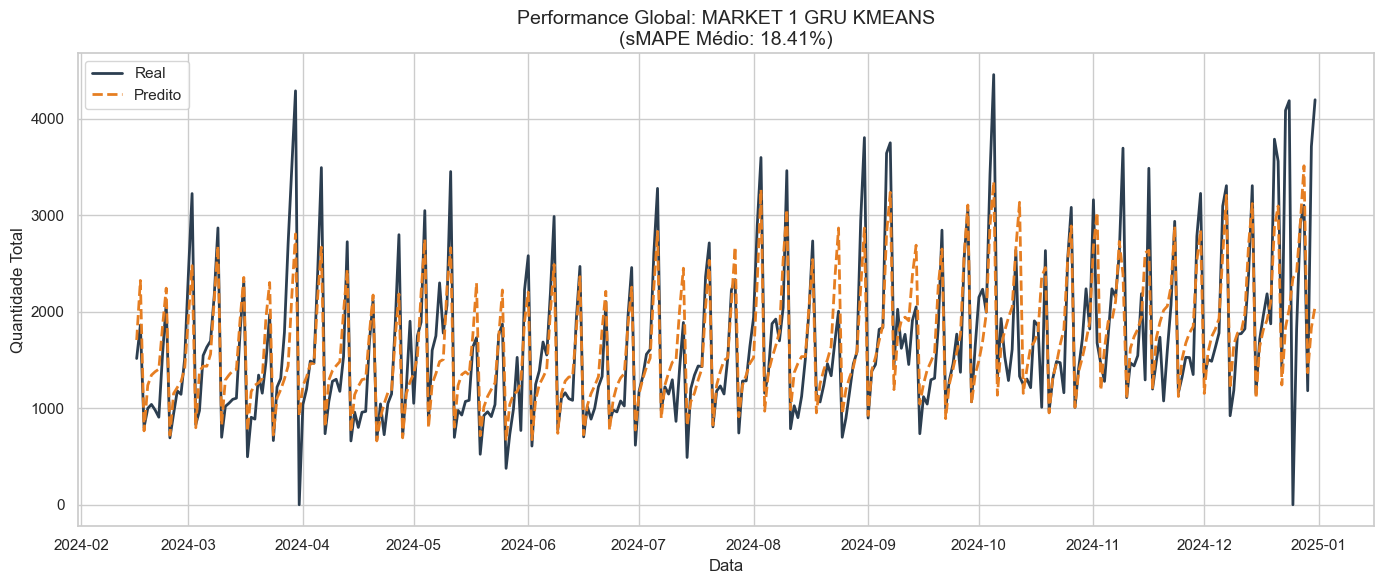

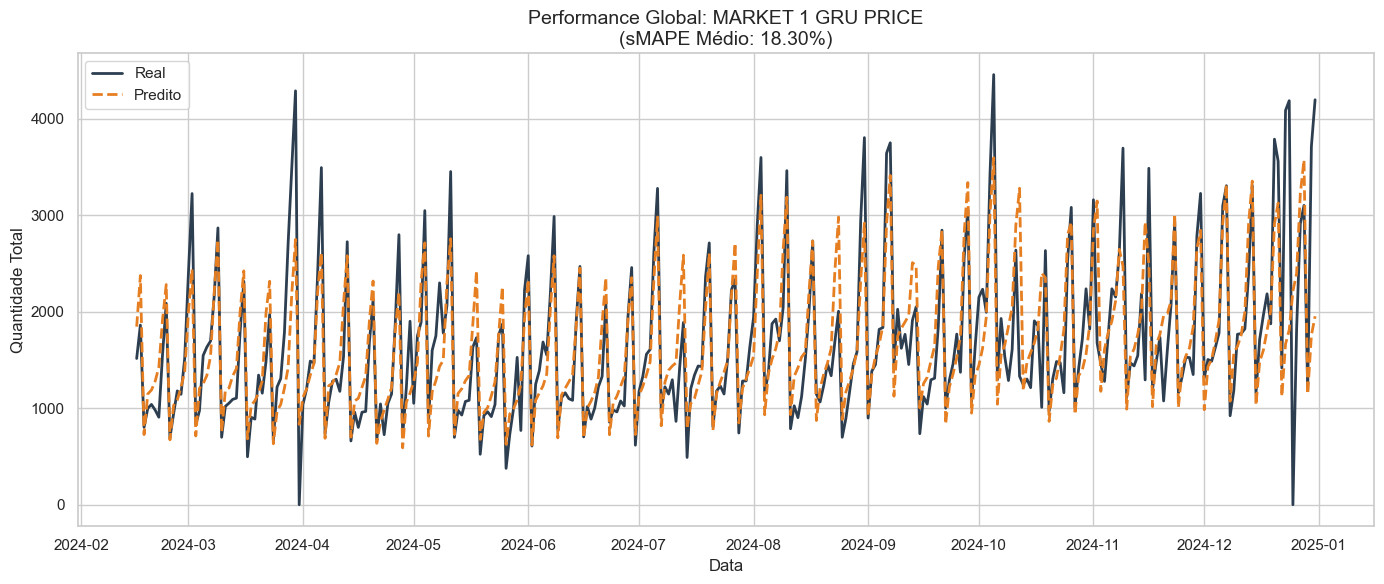

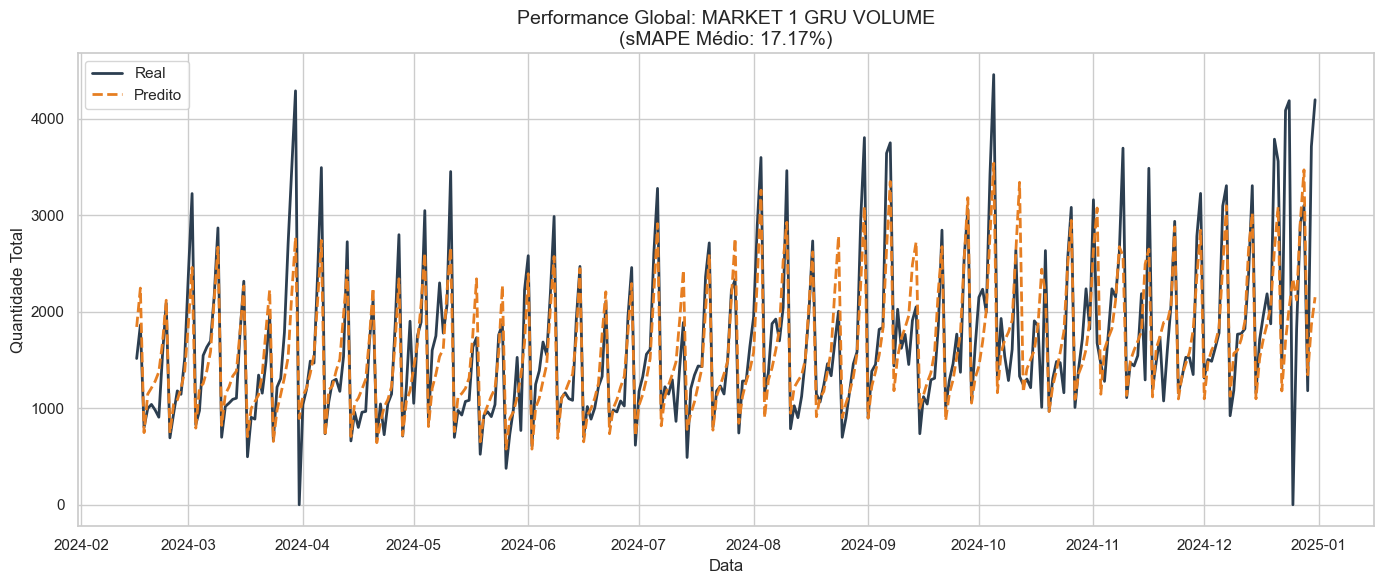

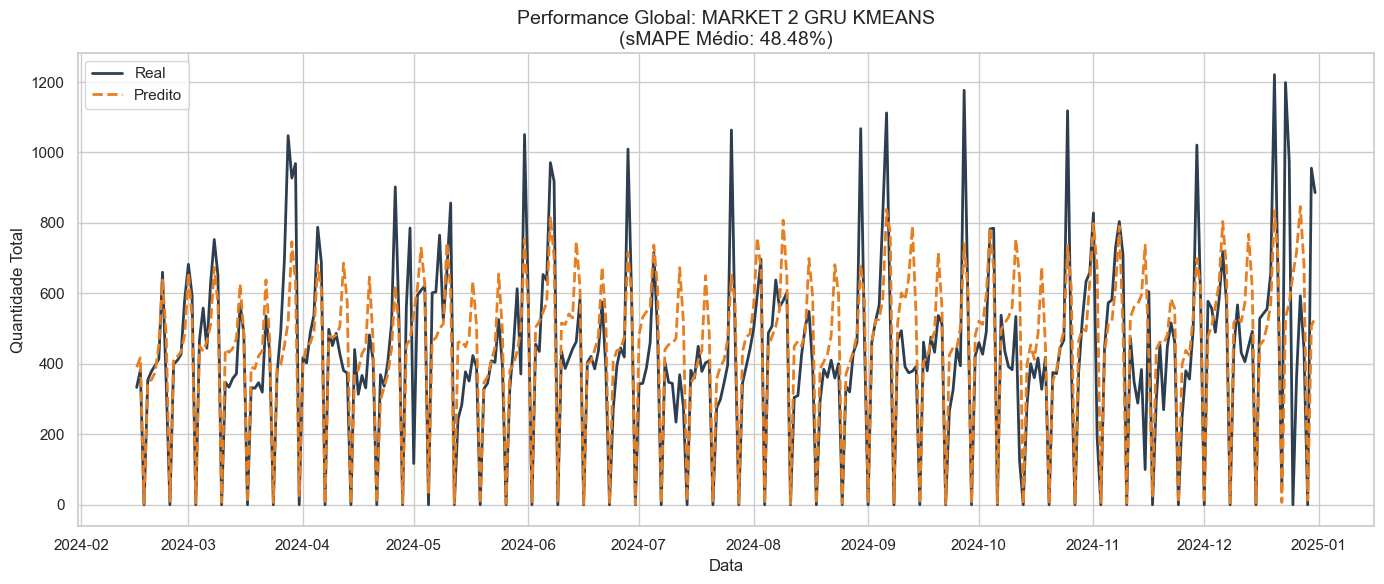

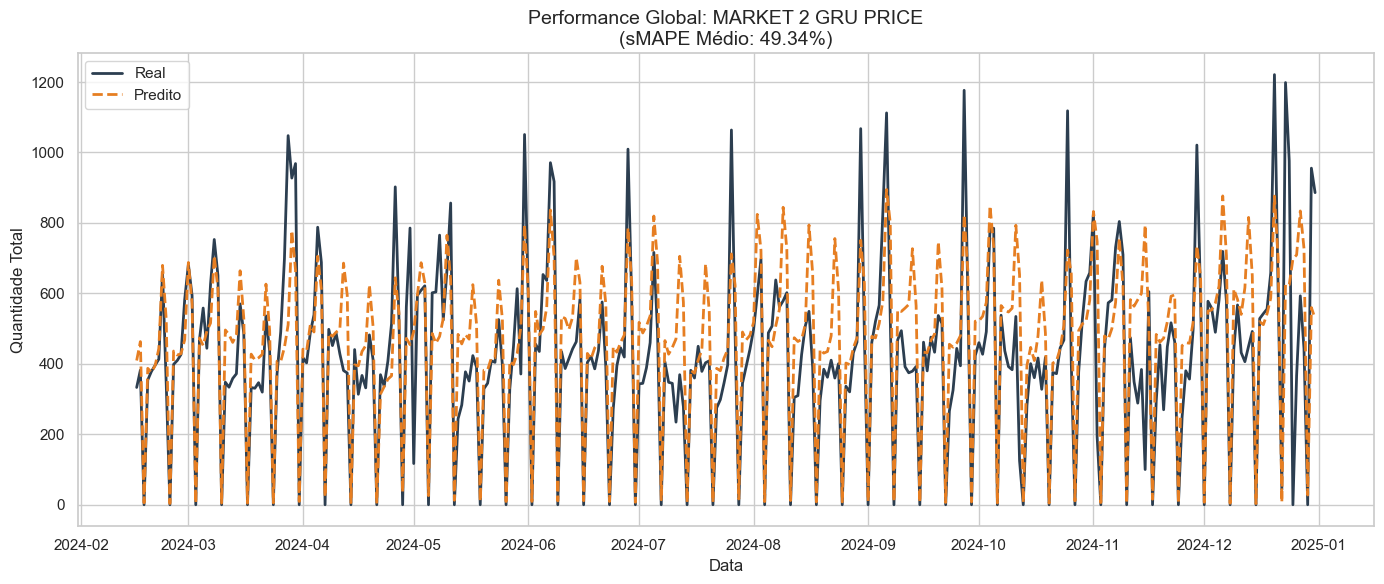

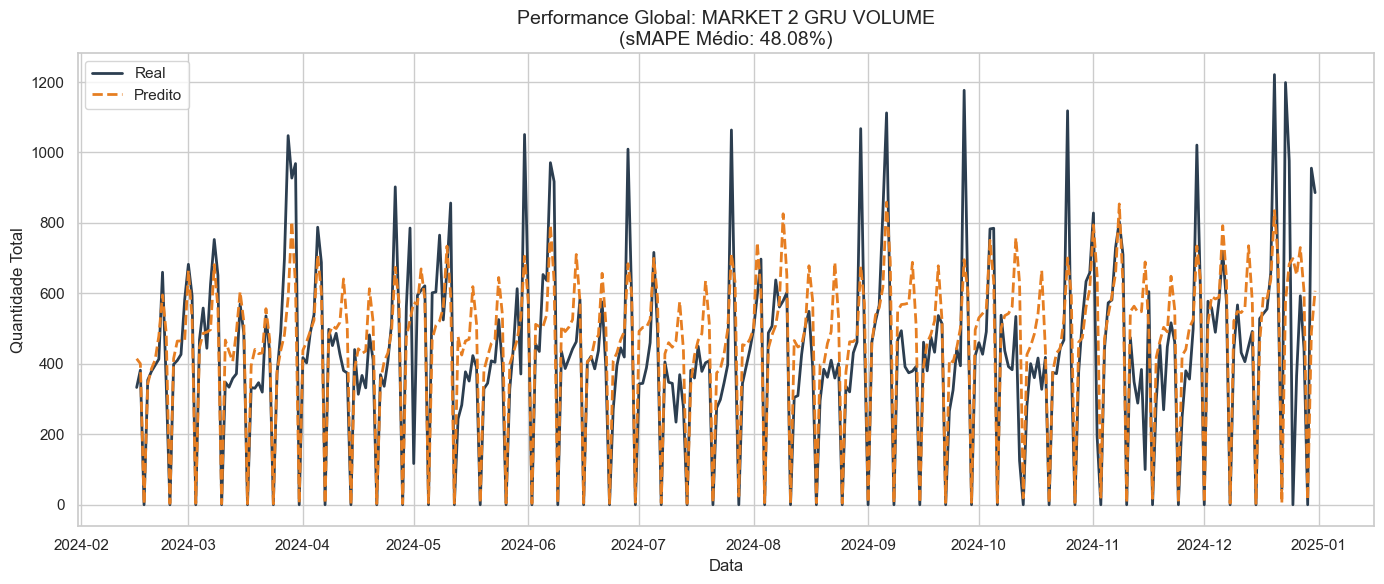

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração visual idêntica ao seu plots.py
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

def calculate_smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        smape = np.abs(y_true - y_pred) / denom * 100
    return np.nanmean(np.where(np.isinf(smape), 0, smape))

# Caminho direto para a pasta da GRU
ROOT = Path("..").resolve()
RESULTS_PATH = ROOT / "Resultados" / "gru"

# Busca os arquivos de predição na pasta
pred_files = list(RESULTS_PATH.glob("*_predictions.csv"))

if not pred_files:
    print(f"[-] Nenhum arquivo encontrado em {RESULTS_PATH}. Verifique se os dados não foram apagados.")
else:
    for file in pred_files:
        try:
            df = pd.read_csv(file)
            df['date'] = pd.to_datetime(df['date'])
            
            # Agrega as vendas de todos os produtos do dia
            df_agg = df.groupby('date')[['y_true', 'y_pred']].sum().reset_index()
            smape_val = calculate_smape(df_agg['y_true'], df_agg['y_pred'])
            
            # Força o título correto substituindo 'lstm' por 'gru' (caso você não tenha renomeado os arquivos)
            nome_limpo = file.stem.replace('_predictions', '').replace('lstm', 'gru').upper().replace('_', ' ')
            
            # Plotagem
            plt.figure()
            plt.plot(df_agg['date'], df_agg['y_true'], label='Real', color='#2c3e50', linewidth=2)
            plt.plot(df_agg['date'], df_agg['y_pred'], label='Predito', color='#e67e22', linestyle='--', linewidth=2)
            
            plt.title(f'Performance Global: {nome_limpo}\n(sMAPE Médio: {smape_val:.2f}%)', fontsize=14)
            plt.xlabel('Data')
            plt.ylabel('Quantidade Total')
            plt.legend()
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"[ERRO] Falha ao plotar {file.name}: {e}")

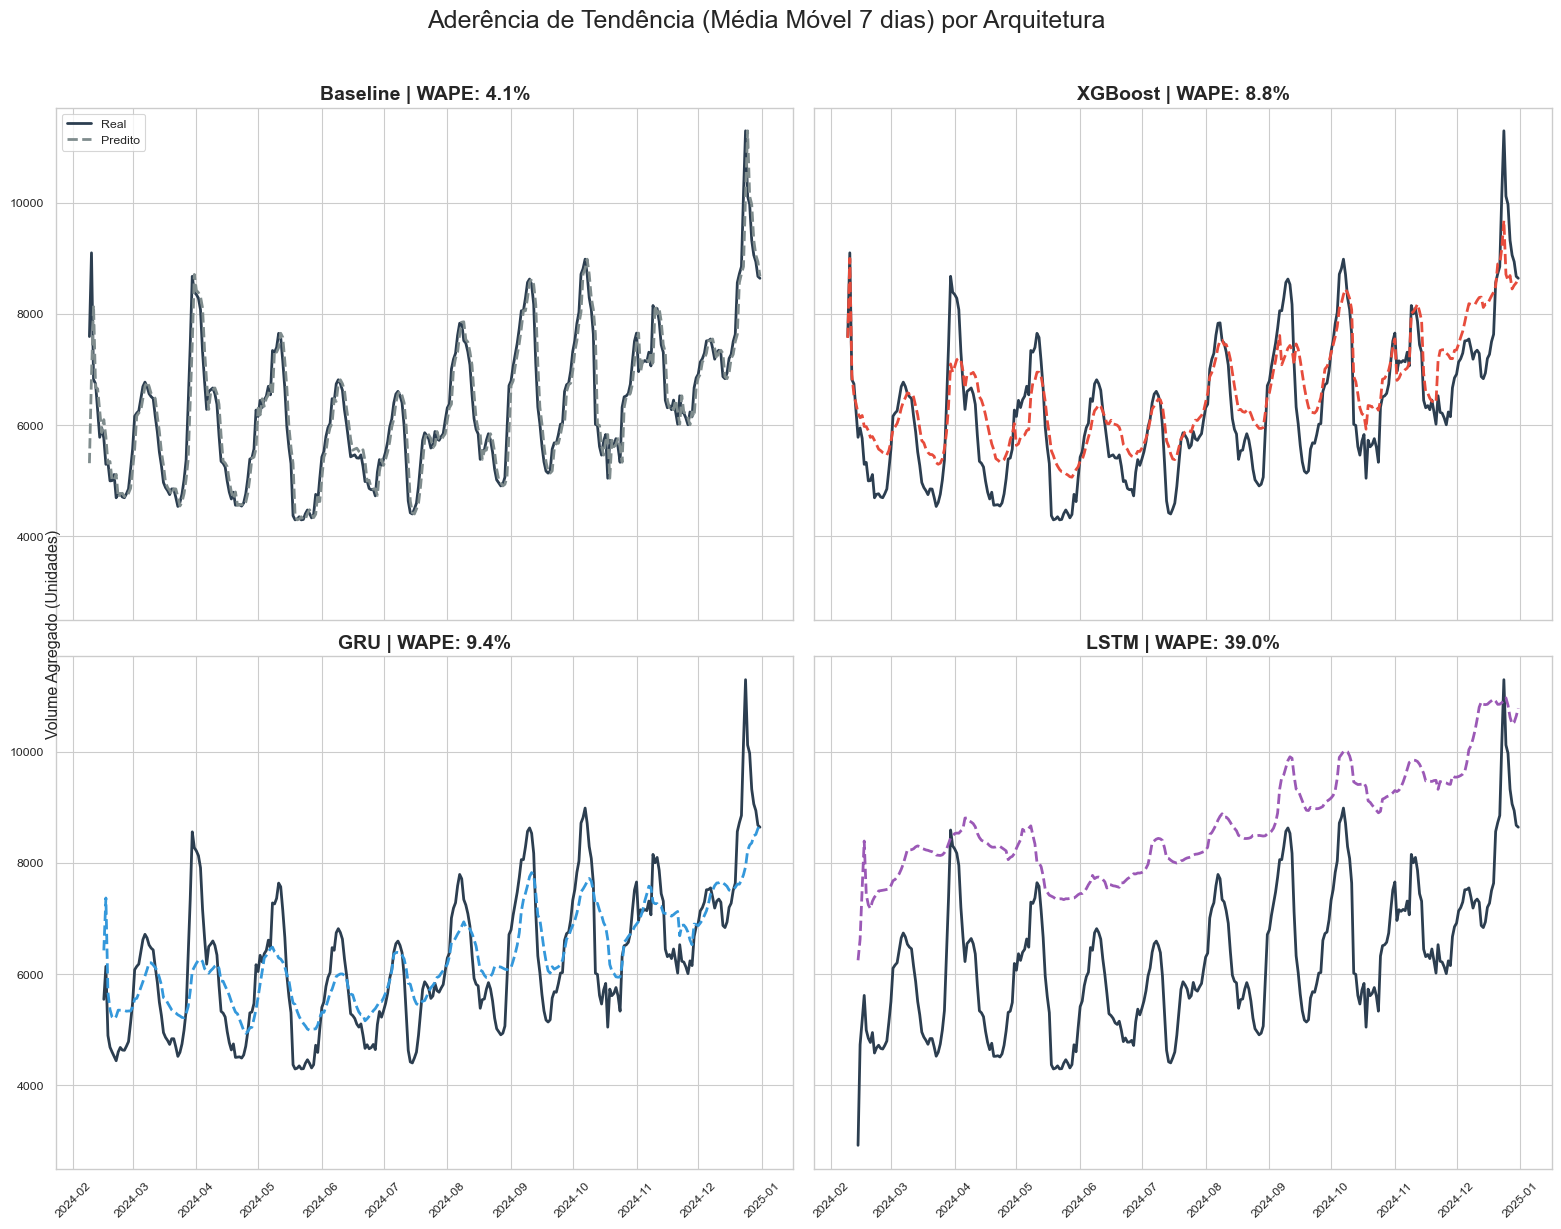

In [2]:
# %% [markdown]
# ## 6. Avaliação de Tendência Direcional (Painel de Aderência)
# Este painel consolida a aderência temporal das predições de cada modelo contra a demanda real observada. A utilização de múltiplos gráficos (Small Multiples) com eixos sincronizados permite a comparação direta da eficácia de cada arquitetura em capturar a tendência de venda, minimizando erros de subestimação em períodos críticos.

# %%
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual profissional
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (16, 12)

def calculate_wape(y_true, y_pred):
    soma_real = np.sum(y_true)
    if soma_real == 0: return 0.0
    return (np.sum(np.abs(y_true - y_pred)) / soma_real) * 100

ROOT = Path(r"C:\Projetos\TCC2").resolve()
MODEL_FOLDERS = {
    "Baseline": ROOT / "Resultados" / "baseline_zero_aware",
    "XGBoost": ROOT / "Resultados" / "xgb",
    "GRU": ROOT / "Resultados" / "gru",
    "LSTM": ROOT / "Resultados" / "lstm"
}

COLORS = ['#7f8c8d', '#e74c3c', '#3498db', '#9b59b6']
JANELA_SUAVIZACAO = 7

# Painel 2x2 para os modelos
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
axes = axes.flatten()

for idx, (model_name, folder_path) in enumerate(MODEL_FOLDERS.items()):
    ax = axes[idx]
    
    if not folder_path.exists():
        ax.set_title(f"{model_name} - Pasta não encontrada")
        continue
        
    # Busca qualquer arquivo de predição na pasta do modelo
    pred_files = list(folder_path.glob("*_predictions.csv"))
    if not pred_files:
        ax.set_title(f"{model_name} - Nenhum arquivo encontrado")
        continue
        
    try:
        # Lê e consolida todos os arquivos da pasta do modelo
        df_list = [pd.read_csv(f) for f in pred_files]
        df_model = pd.concat(df_list, ignore_index=True)
        df_model['date'] = pd.to_datetime(df_model['date'])
        
        # Agrega por data para visualizar a tendência do modelo como um todo
        df_agg = df_model.groupby('date')[['y_true', 'y_pred']].sum().reset_index()
        df_agg = df_agg.sort_values('date')
        
        # Média Móvel
        df_agg['y_true_smooth'] = df_agg['y_true'].rolling(JANELA_SUAVIZACAO, min_periods=1).mean()
        df_agg['y_pred_smooth'] = df_agg['y_pred'].rolling(JANELA_SUAVIZACAO, min_periods=1).mean()
        
        wape = calculate_wape(df_agg['y_true_smooth'], df_agg['y_pred_smooth'])
        
        # Plot
        ax.plot(df_agg['date'], df_agg['y_true_smooth'], label='Real', color='#2c3e50', linewidth=2)
        ax.plot(df_agg['date'], df_agg['y_pred_smooth'], label='Predito', color=COLORS[idx], linestyle='--', linewidth=2)
        
        ax.set_title(f"{model_name} | WAPE: {wape:.1f}%", fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        
        if idx == 0: ax.legend()
            
    except Exception as e:
        ax.set_title(f"Erro ao processar {model_name}")
        print(f"Erro em {model_name}: {e}")

fig.suptitle("Aderência de Tendência (Média Móvel 7 dias) por Arquitetura", fontsize=18, y=1.02)
fig.supylabel("Volume Agregado (Unidades)", x=0.05)
plt.tight_layout()
plt.show()